# Analysis of Goal Scoring in International Soccer Matches

This project investigates whether more goals are scored in **women's international soccer matches** compared to **men's**. To ensure a focused analysis, only **official FIFA World Cup matches** played since **January 1, 2002** are considered, acknowledging that the evolution of the sport and tournament differences could affect performance.

Two datasets—`women_results.csv` and `men_results.csv`—contain the results of every official international match from the 19th century onward. These datasets will be filtered to include only the relevant FIFA World Cup data since 2002.

---

### Research Question

**Are more goals scored in women's international soccer matches than in men's?**

---

### Hypotheses

- **H₀**: The mean number of goals scored in women's international soccer matches is the same as in men's.
- **H₁**: The mean number of goals scored in women's international soccer matches is greater than in men's.

---

*Significance Level: 10%*men's.






### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin
from scipy.stats import mannwhitneyu

### Load men's and women's datasets


In [2]:
men = pd.read_csv("men_results.csv")
women = pd.read_csv("women_results.csv")

In [3]:
men.head(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1872-11-30,Scotland,England,0,0,Friendly
1,1,1873-03-08,England,Scotland,4,2,Friendly
2,2,1874-03-07,Scotland,England,2,1,Friendly
3,3,1875-03-06,England,Scotland,2,2,Friendly
4,4,1876-03-04,Scotland,England,3,0,Friendly
5,5,1876-03-25,Scotland,Wales,4,0,Friendly
6,6,1877-03-03,England,Scotland,1,3,Friendly
7,7,1877-03-05,Wales,Scotland,0,2,Friendly
8,8,1878-03-02,Scotland,England,7,2,Friendly
9,9,1878-03-23,Scotland,Wales,9,0,Friendly


In [4]:
women.head(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1969-11-01,Italy,France,1,0,Euro
1,1,1969-11-01,Denmark,England,4,3,Euro
2,2,1969-11-02,England,France,2,0,Euro
3,3,1969-11-02,Italy,Denmark,3,1,Euro
4,4,1975-08-25,Thailand,Australia,3,2,AFC Championship
5,5,1975-08-25,Hong Kong,New Zealand,0,2,AFC Championship
6,6,1975-08-27,Thailand,Singapore,3,0,AFC Championship
7,7,1975-08-27,New Zealand,Malaysia,3,0,AFC Championship
8,8,1975-08-29,Australia,Singapore,3,0,AFC Championship
9,9,1975-08-29,Hong Kong,Malaysia,0,2,AFC Championship


### Filter the data for the time range and tournament

In [5]:
men["date"] = pd.to_datetime(men["date"])
men_subset = men[(men["date"] > "2002-01-01") & (men["tournament"].isin(["FIFA World Cup"]))]
women["date"] = pd.to_datetime(women["date"])
women_subset = women[(women["date"] > "2002-01-01") & (women["tournament"].isin(["FIFA World Cup"]))]

In [6]:
men_subset.head(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
25164,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup
25165,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup
25166,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup
25167,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup
25168,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup
25169,25169,2002-06-02,England,Sweden,1,1,FIFA World Cup
25170,25170,2002-06-02,Paraguay,South Africa,2,2,FIFA World Cup
25171,25171,2002-06-02,Spain,Slovenia,3,1,FIFA World Cup
25172,25172,2002-06-03,Brazil,Turkey,2,1,FIFA World Cup
25173,25173,2002-06-03,Croatia,Mexico,0,1,FIFA World Cup


In [7]:
women_subset.head(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
1600,1600,2003-09-20,Nigeria,North Korea,0,3,FIFA World Cup
1601,1601,2003-09-20,Norway,France,2,0,FIFA World Cup
1602,1602,2003-09-20,Germany,Canada,4,1,FIFA World Cup
1603,1603,2003-09-20,Japan,Argentina,6,0,FIFA World Cup
1604,1604,2003-09-21,United States,Sweden,3,1,FIFA World Cup
1605,1605,2003-09-21,Brazil,South Korea,3,0,FIFA World Cup
1606,1606,2003-09-21,Australia,Russia,1,2,FIFA World Cup
1607,1607,2003-09-21,China PR,Ghana,1,0,FIFA World Cup
1609,1609,2003-09-24,Norway,Brazil,1,4,FIFA World Cup
1610,1610,2003-09-24,France,South Korea,1,0,FIFA World Cup


### Create group and goals_scored columns

In [8]:
men_subset["group"] = "men"
women_subset["group"] = "women"
men_subset["goals_scored"] = men_subset["home_score"] + men_subset["away_score"]
women_subset["goals_scored"] = women_subset["home_score"] + women_subset["away_score"]

C:\Users\Home\AppData\Local\Temp\ipykernel_7920\548802908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  men_subset["group"] = "men"
C:\Users\Home\AppData\Local\Temp\ipykernel_7920\548802908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  women_subset["group"] = "women"
C:\Users\Home\AppData\Local\Temp\ipykernel_7920\548802908.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

### Determine normality using histograms

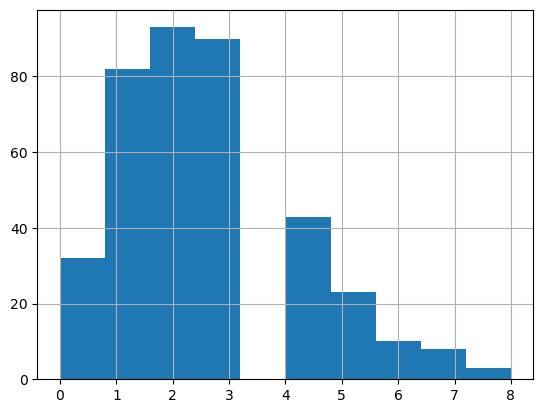

In [9]:
men_subset["goals_scored"].hist()
plt.show()

### Goals scored is not normally distributed, so use Wilcoxon-Mann-Whitney test of two groups

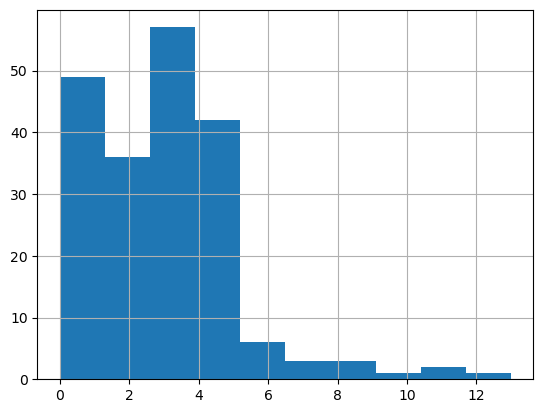

In [10]:
women_subset["goals_scored"].hist()
plt.show()

### Goals scored is not normally distributed, so we will use Wilcoxon-Mann-Whitney test of two groups

### Combine women's and men's data and calculate goals scored in each match

In [11]:
both = pd.concat([women_subset, men_subset], axis=0, ignore_index=True)

### Transform the data for the pingouin Mann-Whitney U t-test

In [12]:
both_subset = both[["goals_scored", "group"]]
both_subset_wide = both_subset.pivot(columns="group", values="goals_scored")

In [13]:
both_subset.head(20)

,goals_scored,group
0,3,women
1,2,women
2,5,women
3,6,women
4,4,women
5,3,women
6,3,women
7,1,women
8,5,women
9,1,women


In [14]:
both_subset_wide.head(20)

group,men,women
0,NaN,3.0
1,NaN,2.0
2,NaN,5.0
3,NaN,6.0
4,NaN,4.0
5,NaN,3.0
6,NaN,3.0
7,NaN,1.0
8,NaN,5.0
9,NaN,1.0


### Perform right-tailed Wilcoxon-Mann-Whitney test with pingouin

In [15]:
results_pg = pingouin.mwu(x=both_subset_wide["women"],
                          y=both_subset_wide["men"],
                          alternative="greater")

### Alternative SciPy solution: Perform right-tailed Wilcoxon-Mann-Whitney test with scipy

In [16]:
results_scipy = mannwhitneyu(x=women_subset["goals_scored"],
                             y=men_subset["goals_scored"],
                             alternative="greater")

### Extract p-value as a float

In [17]:
p_val = results_pg["p-val"].values[0]

### Determine hypothesis test result using sig. level

In [18]:
if p_val <= 0.1:
    result = "reject"
else:
    result = "fail to reject"

### Results of the test

In [19]:
print(f"P-value: {p_val} Result: {result}")

P-value: 0.005106609825443641 Result: reject
